In [ ]:
#import librarys and import dataset
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("llmdata.csv")

df.head()

,model_name,model_slug,provider,provider_slug,aa_id,aa_intelligence_index,aa_coding_index,aa_math_index,composite_benchmark,mmlu_pro,...,arena_elo_ci95,arena_votes,parameter_count,release_year,is_open_source,intelligence_per_dollar,price_performance_ratio,elo_benchmark_blend,speed_per_dollar,scrape_date
0,GPT-5.4 (xhigh),gpt-5-4,OpenAI,openai,a89c4b28-2d8c-456e-88ea-255fb51fd2b6,57.2,57.3,NaN,63.40,NaN,...,8.0,5618.0,500.0,2026.0,False,10.17,33.53,80.68,15.94,2026-03-31
1,Gemini 3.1 Pro Preview,gemini-3-1-pro-preview,Google,google,bbd93ebe-80da-4594-bb19-61e69d0331df,57.2,55.5,NaN,65.90,NaN,...,6.0,15809.0,NaN,2026.0,False,12.71,38.66,96.02,26.71,2026-03-31
2,GPT-5.3 Codex (xhigh),gpt-5-3-codex,OpenAI,openai,59b5b14b-5365-4ee7-824a-18a8e6309644,54.0,53.1,NaN,61.53,NaN,...,NaN,NaN,500.0,2026.0,False,11.22,34.96,NaN,19.01,2026-03-31
3,"Claude Opus 4.6 (Adaptive Reasoning, Max Effort)",claude-opus-4-6-adaptive,Anthropic,anthropic,53c98840-47af-49aa-94e6-469fb17e9a1b,53.0,48.1,NaN,59.40,NaN,...,NaN,NaN,NaN,2025.0,False,5.30,24.77,NaN,6.06,2026-03-31
4,"Claude Sonnet 4.6 (Adaptive Reasoning, Max Eff...",claude-sonnet-4-6-adaptive,Anthropic,anthropic,df8d14e0-3997-4e4d-b4ad-9c047acc9c69,51.7,50.9,NaN,54.77,NaN,...,NaN,NaN,NaN,2025.0,False,8.62,28.14,NaN,12.90,2026-03-31


In [9]:
#keep only needed columns for analysis and clean data
data_df = df[["release_year", "aa_intelligence_index", "blended_cost_usd_per_1m"]]
data_df = data_df.dropna(subset=["release_year", "aa_intelligence_index", "blended_cost_usd_per_1m"])

#change the release year to int insteadd of float so it looks cleaner is the charts
data_df["release_year"] = data_df["release_year"].astype(int)
data_df.head()

,release_year,aa_intelligence_index,blended_cost_usd_per_1m
0,2026,57.2,5.625
1,2026,57.2,4.500
2,2026,54.0,4.813
3,2025,53.0,10.000
4,2025,51.7,6.000


In [10]:
#
data_df["release_year"].value_counts().sort_index()

release_year
2023      1
2024     43
2025     49
2026    130
Name: count, dtype: int64

In [14]:
#avg the years and group by intellegine and cost so you can graph it

year_avg = data_df = data_df.groupby("release_year")[["aa_intelligence_index", "blended_cost_usd_per_1m"]].mean()
year_avg = year_avg.round(4)
year_avg

,aa_intelligence_index,blended_cost_usd_per_1m
release_year,,
2023,9.7000,0.1000
2024,13.7163,9.6627
2025,23.7939,2.9684
2026,28.4408,1.3496


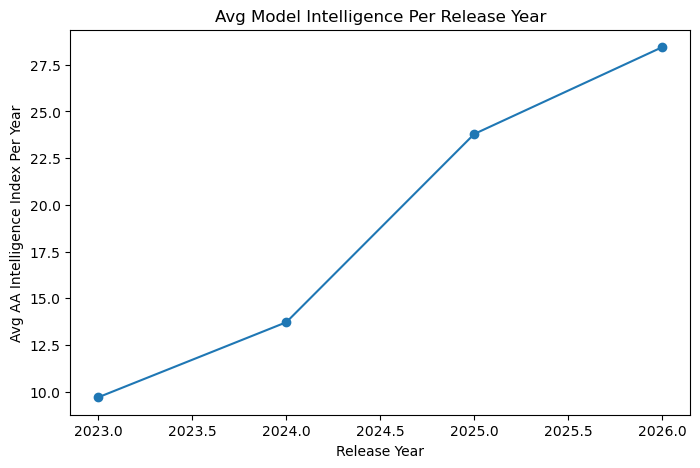

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(year_avg.index, year_avg["aa_intelligence_index"], marker="o")
plt.xlabel("Release Year")
plt.ylabel("Avg AA Intelligence Index Per Year")
plt.title("Avg Model Intelligence by Release Year")
plt.show()

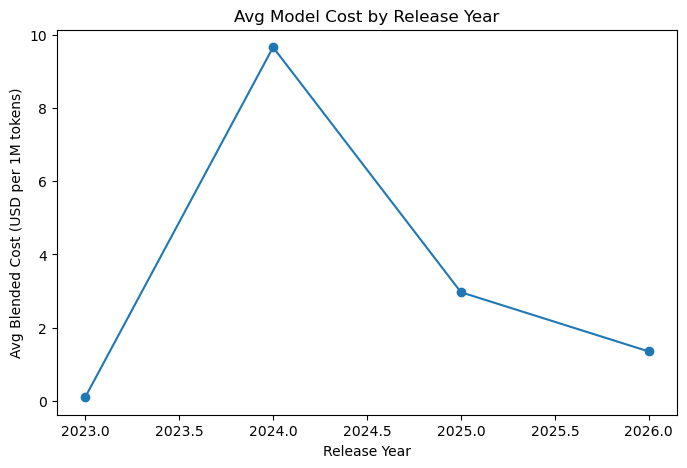

In [18]:
plt.figure(figsize=(8,5))
plt.plot(year_avg.index, year_avg["blended_cost_usd_per_1m"], marker="o")
plt.xlabel("Release Year")
plt.ylabel("Avg Blended Cost (USD per 1M tokens)")
plt.title("Avg Model Cost by Release Year")
plt.show()